# STEEL PRODUCTION ANALYSIS - FULL PIPELINE NOTEBOOK


In [3]:

import sys
import os
import warnings
import time
import pickle
import json
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')

print("\n" + "="*100)
print("MASTER NOTEBOOK - COMPLETE DATA ANALYSIS PIPELINE")
print("="*100)




MASTER NOTEBOOK - COMPLETE DATA ANALYSIS PIPELINE


# CONFIGURATION

In [4]:

CONFIG = {
    'train_path': "data/normalized_train_data.csv",
    'test_path': "data/normalized_test_data.csv",
    'target_col': 'output',
    'test_size': 0.2,
    'n_features': 21,
    'random_state': 42,
}

print("\n[CONFIG] Pipeline Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")



[CONFIG] Pipeline Configuration:
  train_path: data/normalized_train_data.csv
  test_path: data/normalized_test_data.csv
  target_col: output
  test_size: 0.2
  n_features: 21
  random_state: 42


In [5]:
# CREATE OUTPUT DIRECTORIES
os.makedirs('results', exist_ok=True)
os.makedirs('results/models', exist_ok=True)
os.makedirs('results/predictions', exist_ok=True)
os.makedirs('figures', exist_ok=True)


# DATA LOADING


In [6]:

print("\n" + "="*100)
print("STEP 1: DATA LOADING & VALIDATION")
print("="*100)

try:
    from scripts._01_data_loading import load_data
    
    print("\n[INFO] Importing data loading module...")
    
    df_train, df_test = load_data(
        train_path=CONFIG['train_path'],
        test_path=CONFIG['test_path'],
        target_col=CONFIG['target_col'],
        verbose=True
    )
    
    print("\n[SUCCESS] Data loaded successfully!")
    
except Exception as e:
    print(f"\n[ERROR] Failed to load data: {str(e)}")
    sys.exit(1)



STEP 1: DATA LOADING & VALIDATION

[INFO] Importing data loading module...

[DATA LOADING] Loading raw data

[1] Loading training data from: data/normalized_train_data.csv
[2] Loading test data from: data/normalized_test_data.csv

[3] Validating data structure...
   Target column 'output' found in both datasets

[4] Checking missing values...
  Train: 0 missing values
  Test: 0 missing values

[5] Data statistics:
  Train shape: (7642, 22)
  Test shape: (3337, 22)

  Target statistics (train):
    Mean: 0.5117
    Std:  0.0834
    Min:  0.0000
    Max:  1.0000

  Feature columns: 21
    input1, input2, input3, input4, input5...

[SUCCESS] Data loaded successfully!



#  EXPLORATORY DATA ANALYSIS (EDA)



STEP 2: EXPLORATORY DATA ANALYSIS

[INFO] Importing EDA module...

[EDA] EXPLORATORY DATA ANALYSIS

Dataset shape: (7642, 22)
Target column: output

[1/8] Plotting correlation matrix...


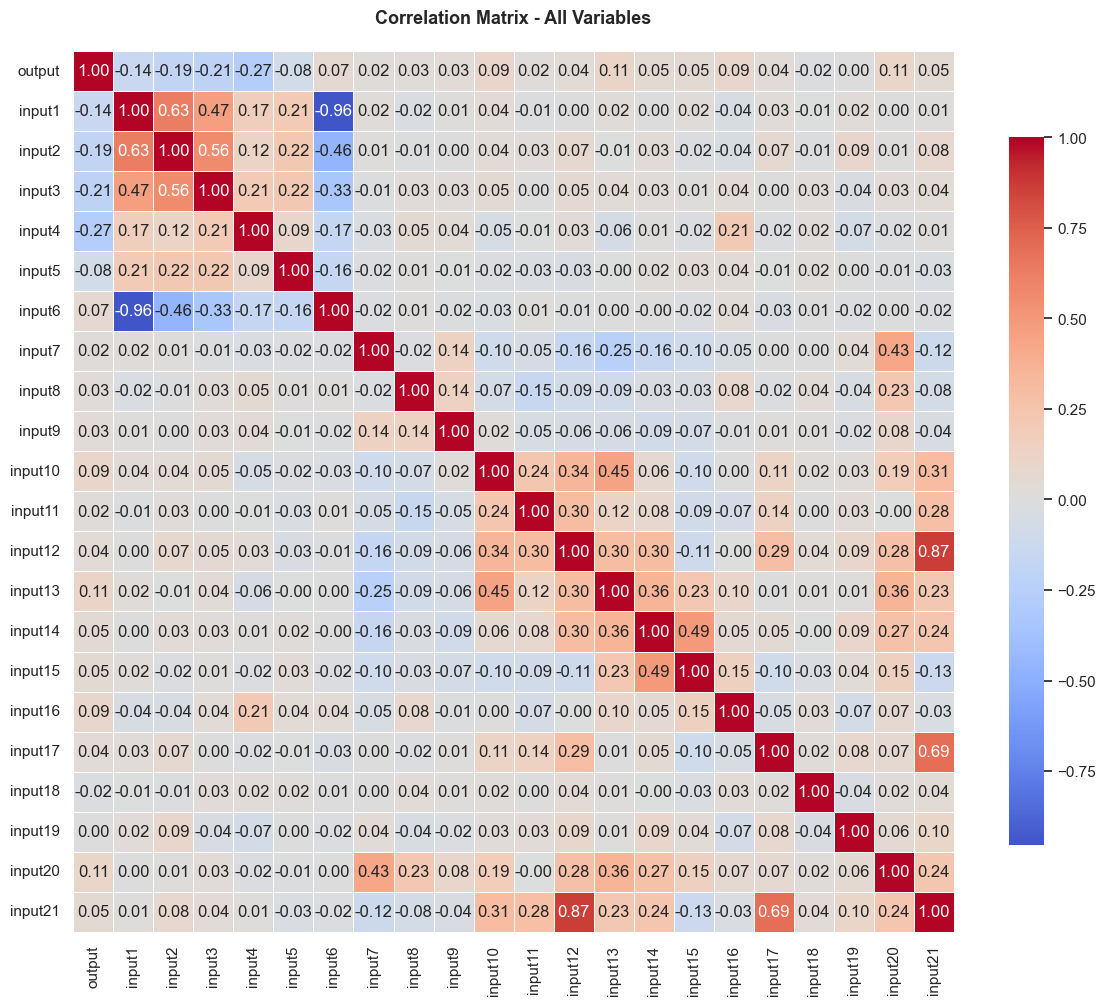

[SAVED] ../figures\01_correlation_matrix.png
[2/8] Plotting correlation with target...


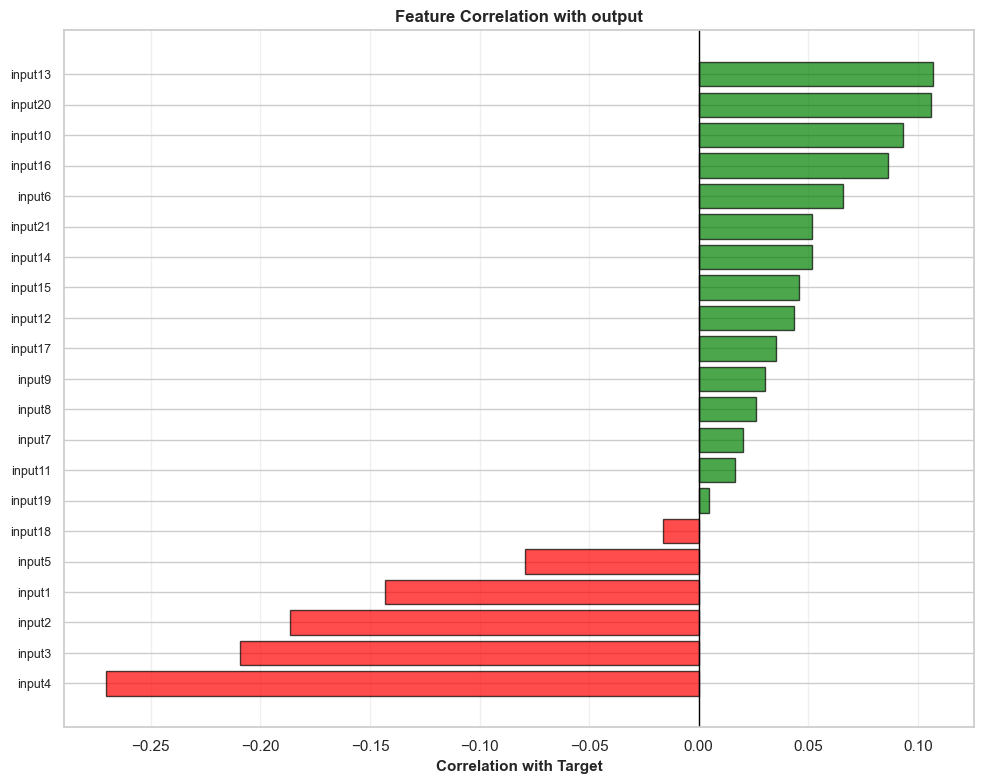

[SAVED] ../figures\02_correlation_with_target.png
[3/8] Plotting simple histograms...


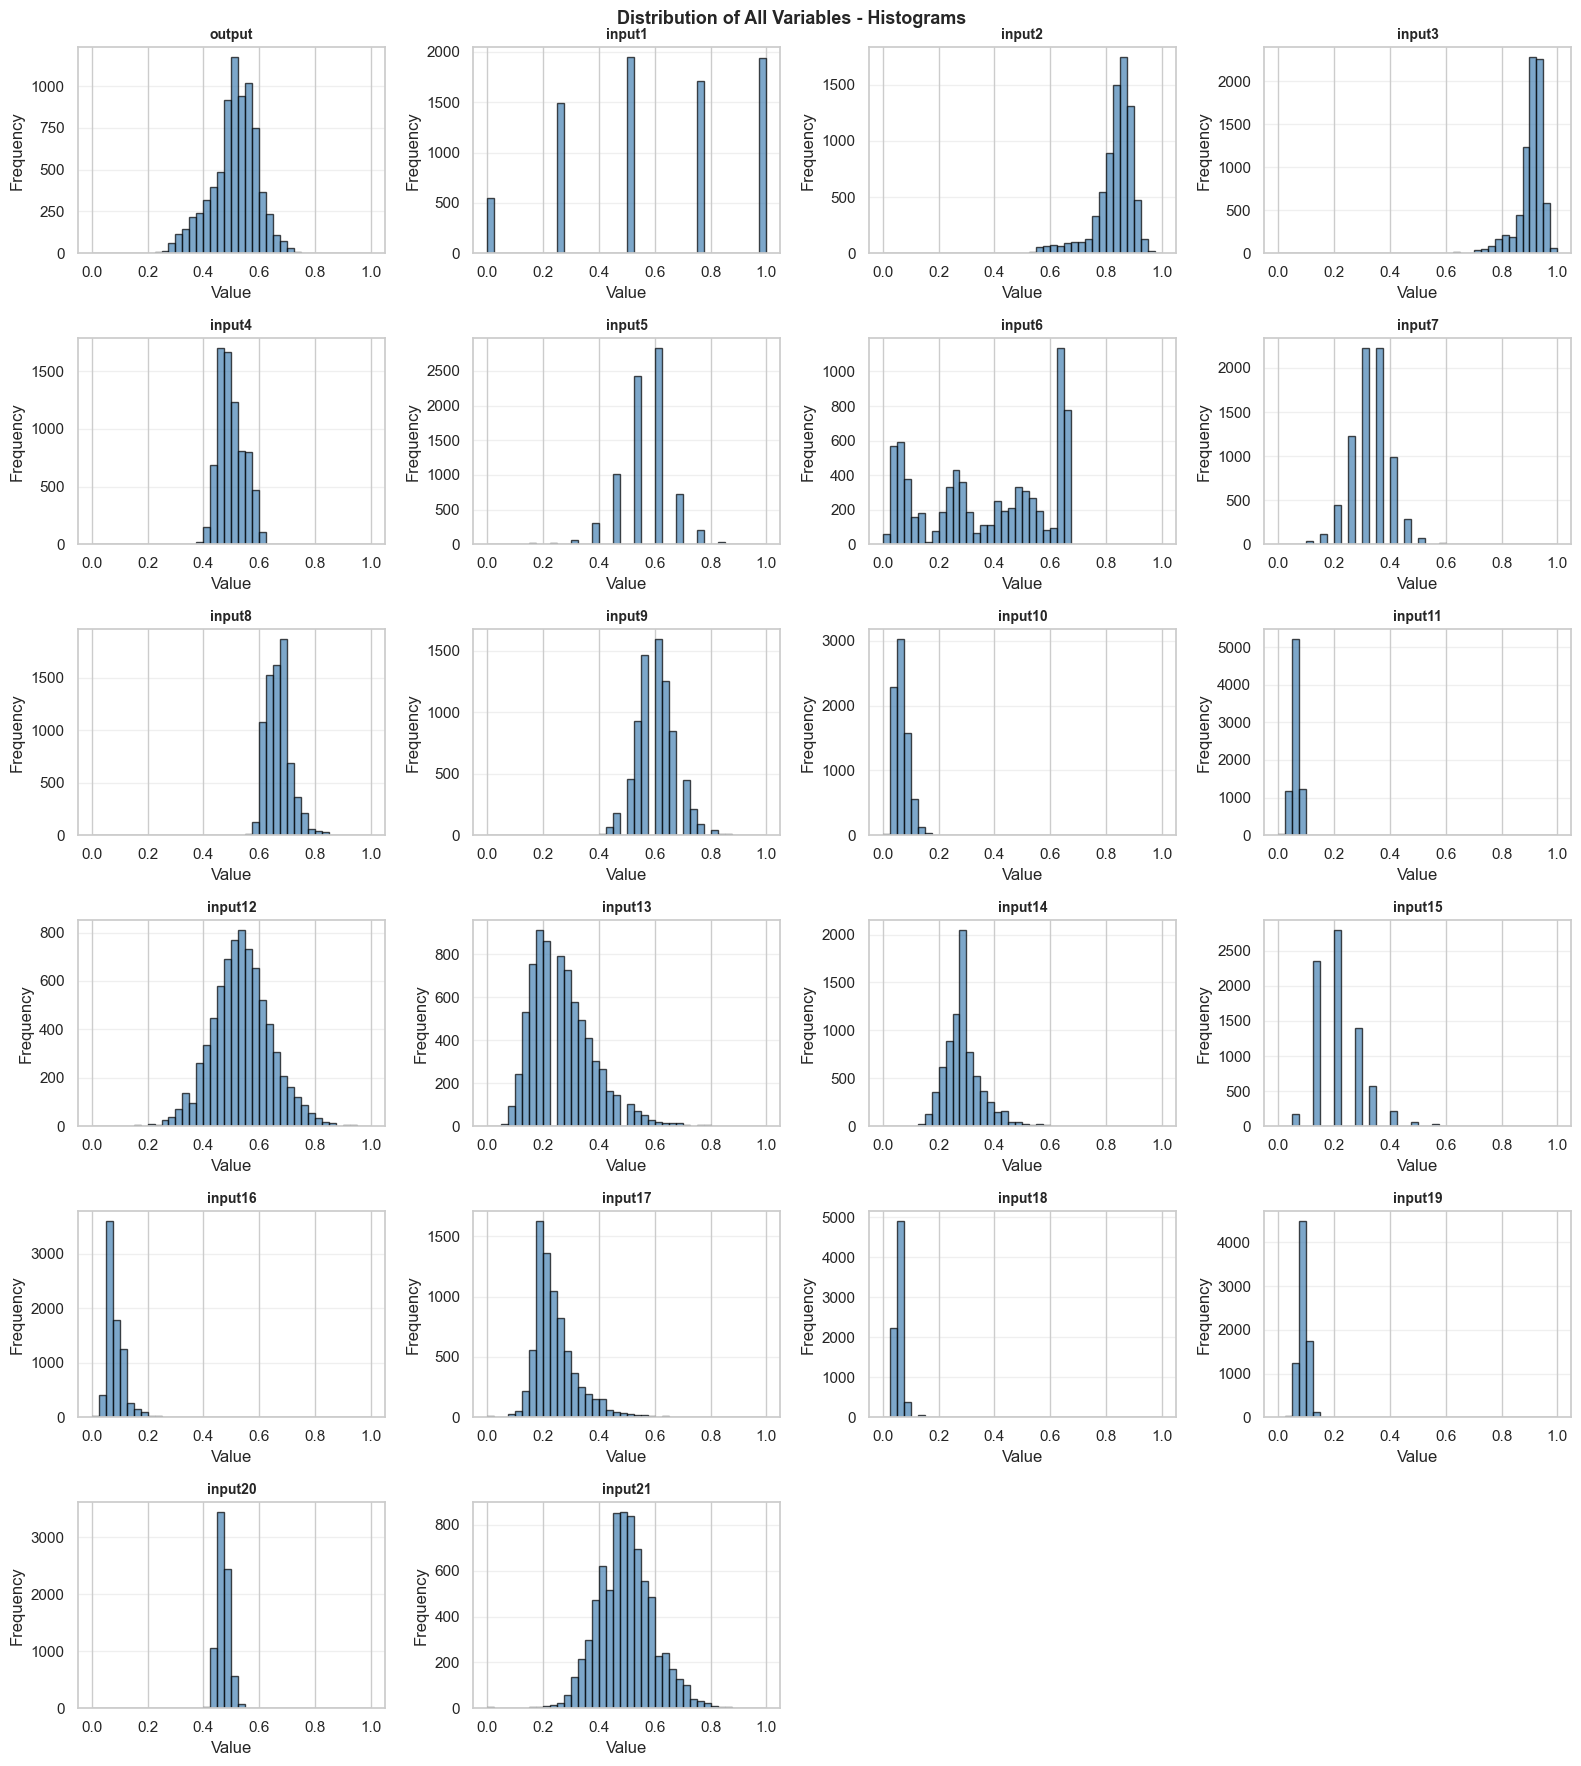

[SAVED] ../figures\03_histograms.png
[4/8] Plotting histograms with KDE...


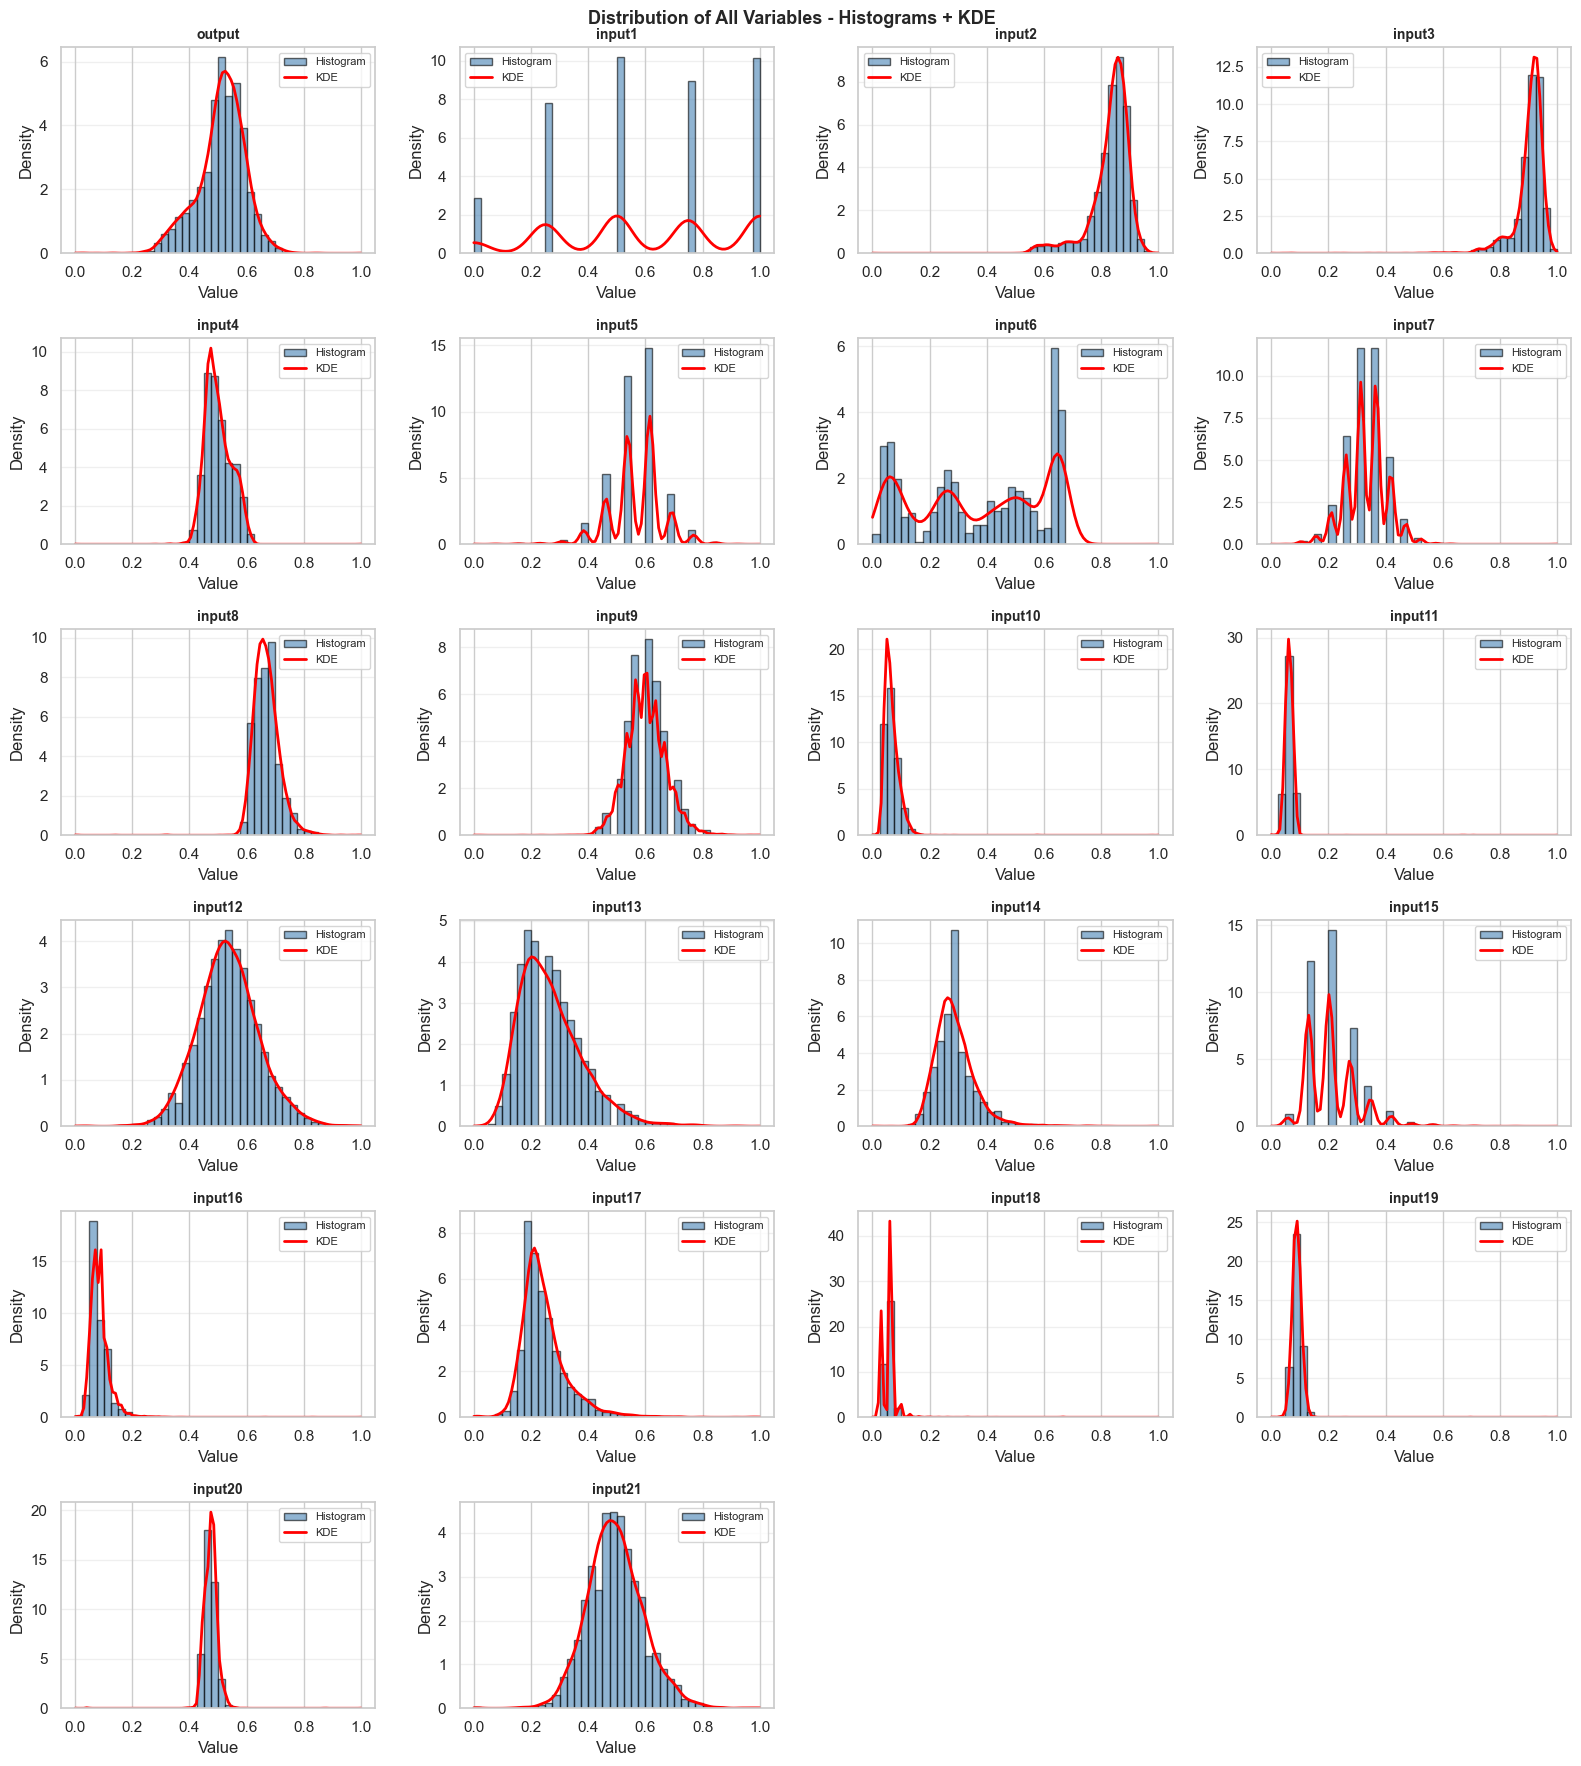

[SAVED] ../figures\04_histograms_kde.png
[5/8] Plotting boxplots...


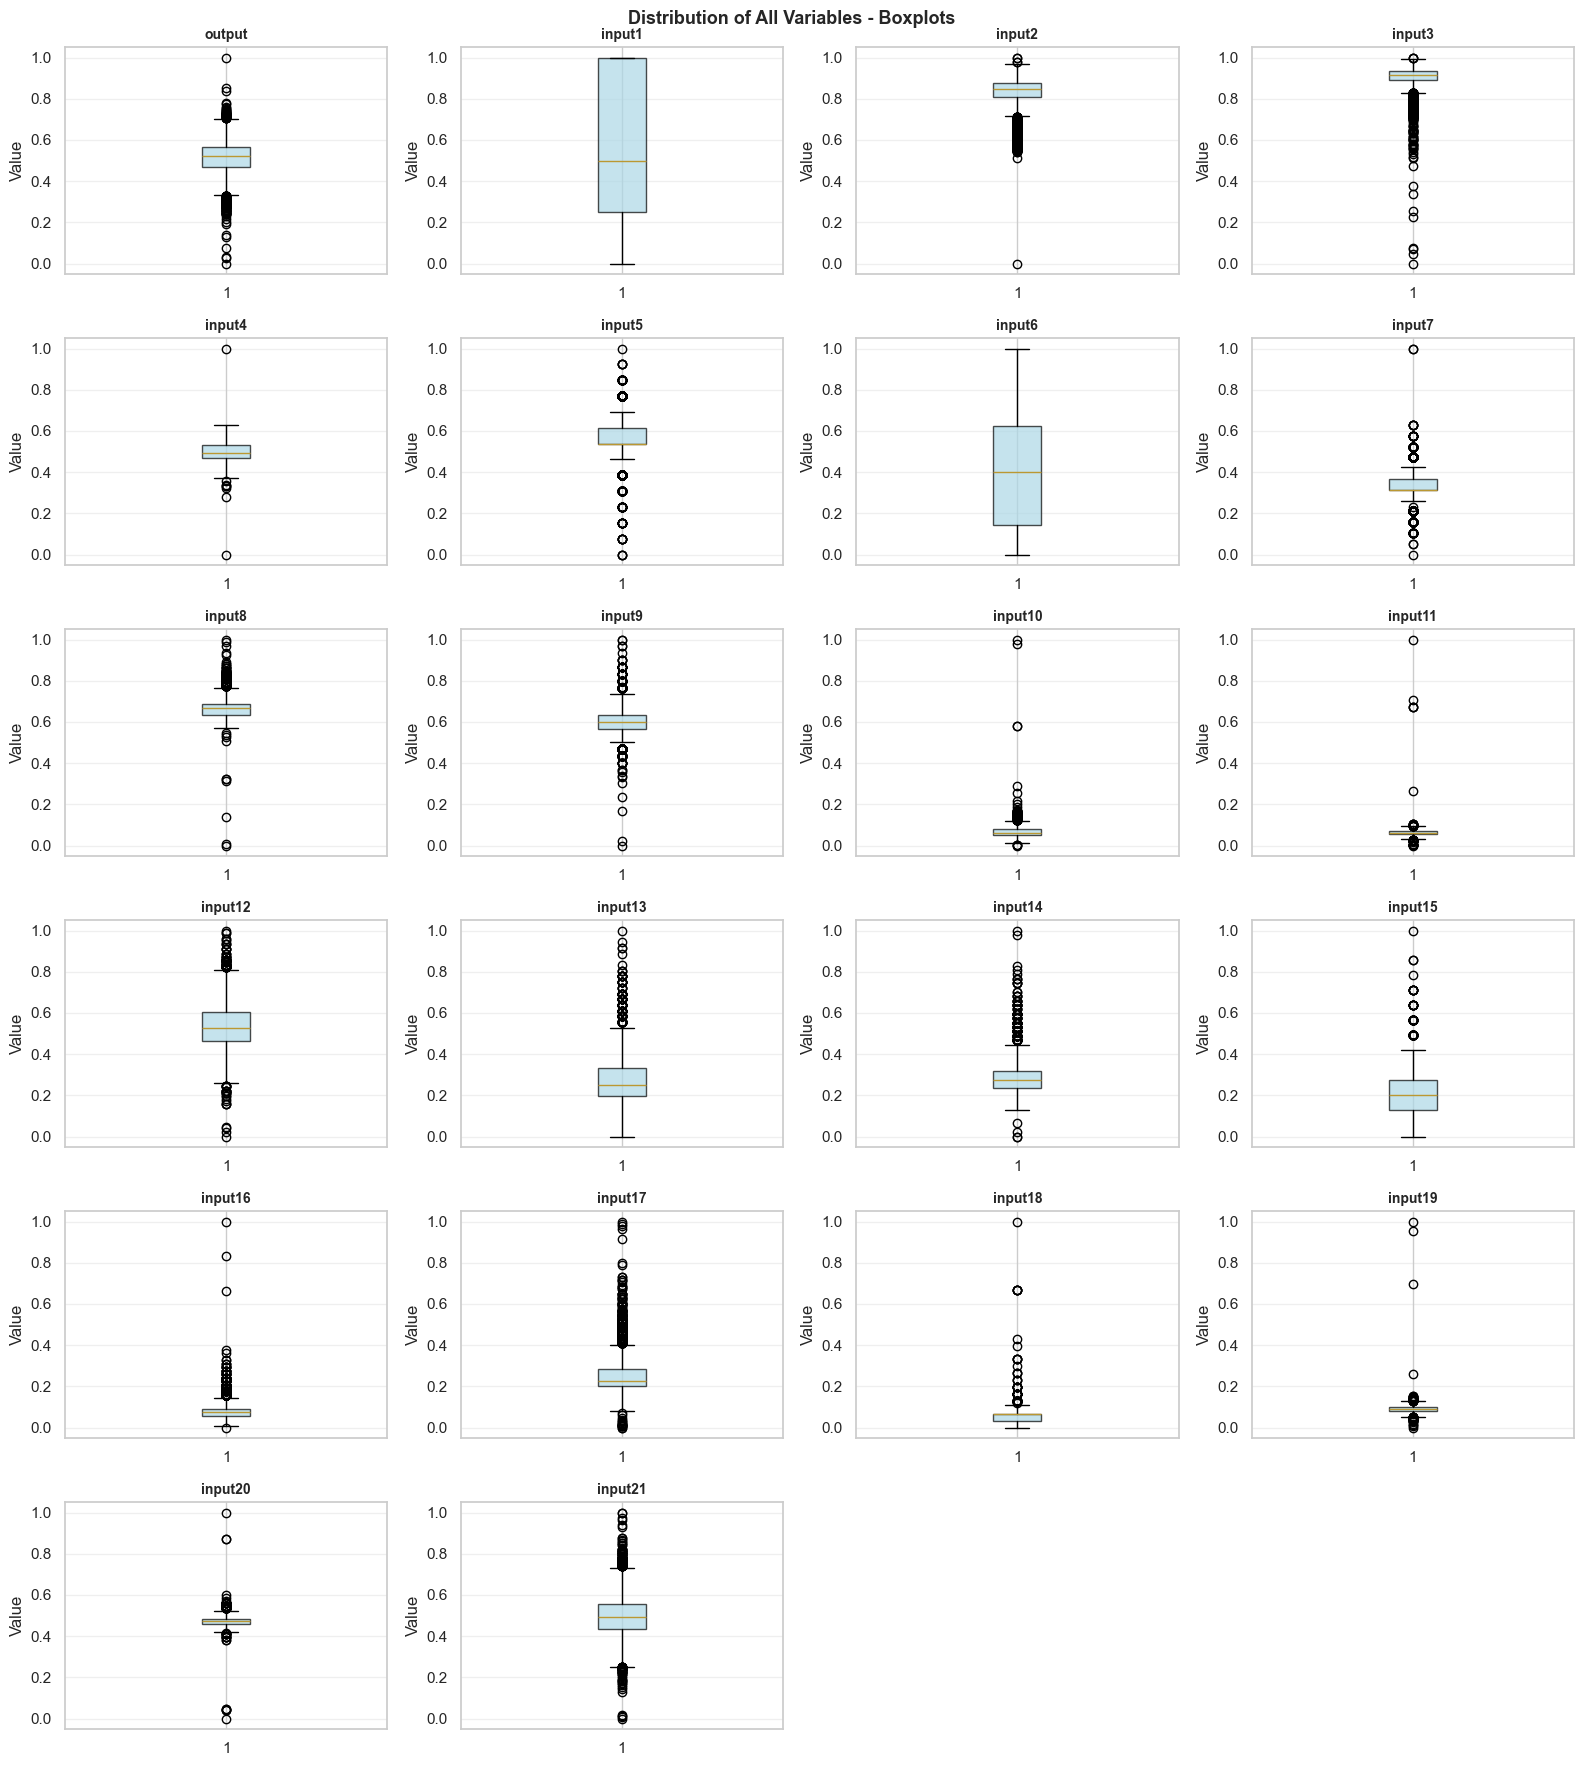

[SAVED] ../figures\05_boxplots.png
[6/8] Plotting boxplots with statistics...


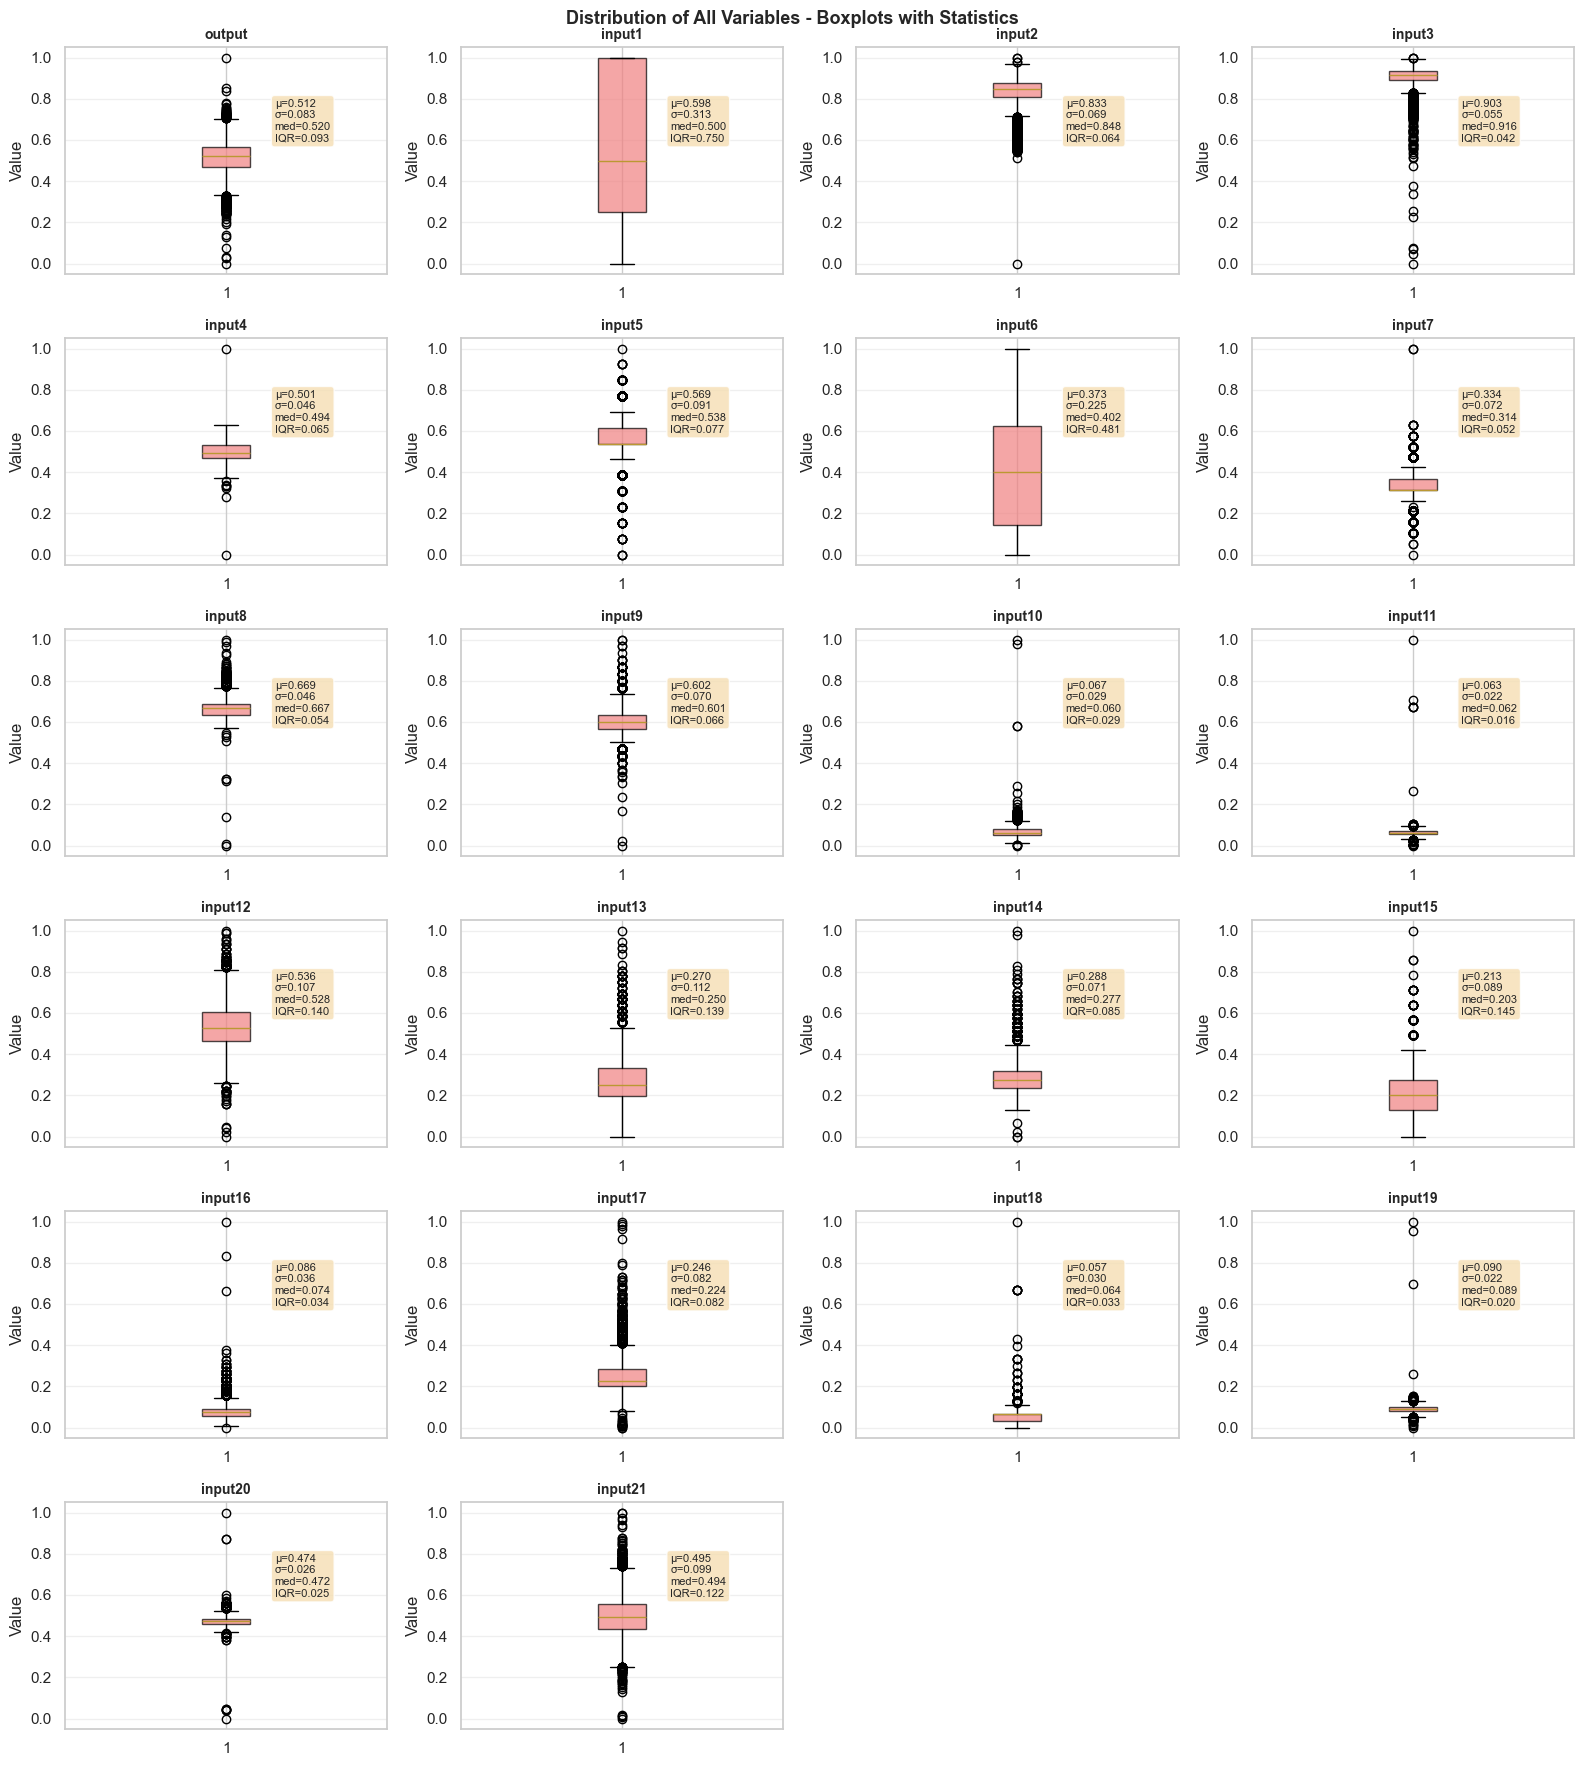

[SAVED] ../figures\06_boxplots_with_stats.png
[7/8] Plotting target distribution...


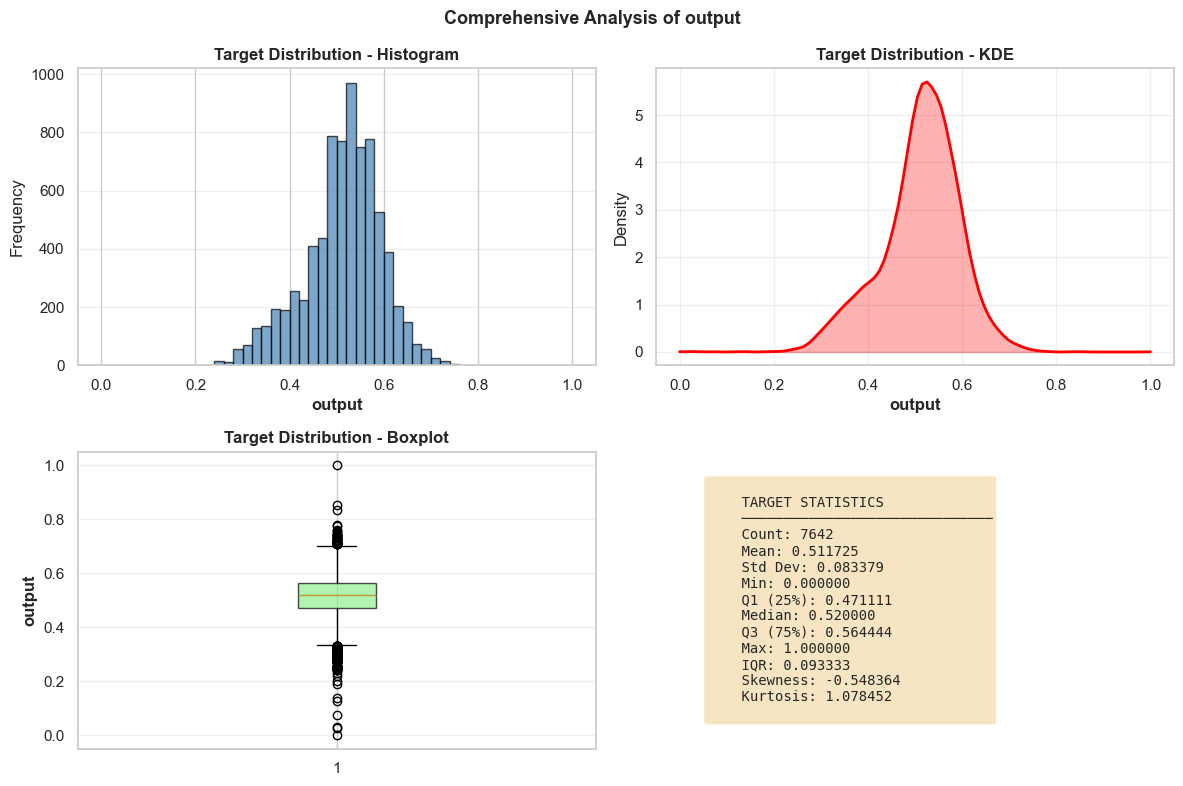

[SAVED] ../figures\07_target_distribution.png
[8/8] Plotting skewness and kurtosis...


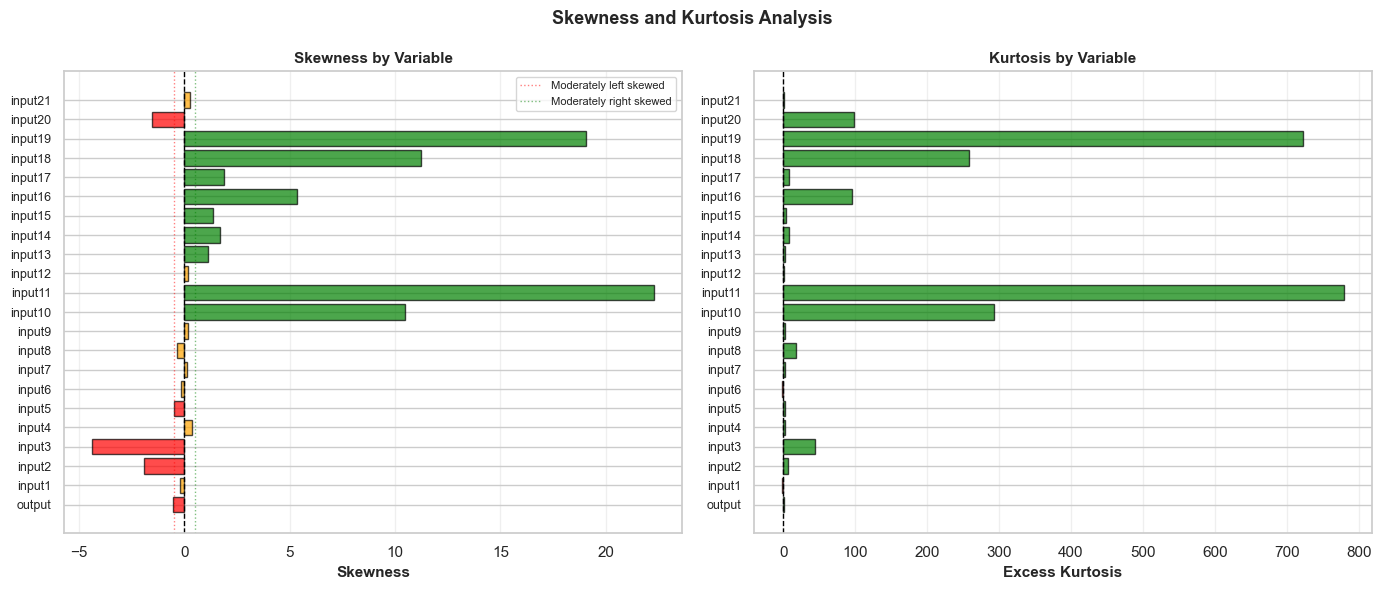

[SAVED] ../figures\08_skewness_kurtosis.png

 EDA COMPLETE - 8 visualizations generated

[SUCCESS] EDA completed successfully!


In [7]:

print("\n" + "="*100)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("="*100)

try:
    from scripts._03_eda import run_eda
    
    print("\n[INFO] Importing EDA module...")
    
    run_eda(
        df=df_train,
        target_col=CONFIG['target_col']
    )
    
    print("\n[SUCCESS] EDA completed successfully!")
    
except Exception as e:
    print(f"\n[ERROR] EDA failed: {str(e)}")



# DATA PREPROCESSING & FEATURE SELECTION


In [8]:

print("\n" + "="*100)
print("STEP 3: DATA PREPROCESSING & FEATURE SELECTION")
print("="*100)

try:
    from scripts._02_data_preprocessing import preprocess_data_improved
    
    print("\n[INFO] Importing preprocessing module...")
    
    (X_train, X_val, X_test,
     y_train_res, y_val_res, y_test_res,
     y_train, y_val, y_test,
     scaler, feature_names, y_train_mean) = preprocess_data_improved(
        df_train=df_train,
        df_test=df_test,
        target_col=CONFIG['target_col'],
        test_size=CONFIG['test_size'],
        n_features=CONFIG['n_features'],
        verbose=True
    )
    
    print("\n[SUCCESS] Preprocessing completed successfully!")
    
except Exception as e:
    print(f"\n[ERROR] Preprocessing failed: {str(e)}")
    sys.exit(1)



STEP 3: DATA PREPROCESSING & FEATURE SELECTION

[INFO] Importing preprocessing module...

[PREPROCESSING] Data preprocessing with R² optimization

[1] Extracting target 'output' from data...
  ✓ Features: 21, Target samples: 7642

[2] Splitting data (train/val ratio: 80.0%/20.0%)...
  ✓ Train: (6113, 21), Val: (1529, 21)

[3] Selecting top 21 features (mutual information)...
  ✓ Selected features: input1, input2, input3, input4, input5...

[4] Scaling features (fit on train only)...
  ✓ Scaling complete (train mean ≈ 0, std ≈ 1)

[5] Preparing residuals (for residual learning)...
  ✓ Train target mean: 0.5115
  ✓ Train residuals mean: -0.000000 (should be ≈0)
  ✓ Train residuals std: 0.0838

[6] Summary:
  Train shape: (6113, 21)
  Val shape: (1529, 21)
  Test shape: (3337, 21)
  Selected features: 21/21

[SUCCESS] Preprocessing completed successfully!



#  MODEL TRAINING


In [9]:

print("\n" + "="*100)
print("STEP 4: MODEL TRAINING (25+ Regression Models)")
print("="*100)

try:
    from scripts._04_model_training import train_all_models_improved, evaluate_model, apply_residual_learning, set_y_train_mean
    
    print("\n[INFO] Importing model training module...")
    
    df_results = train_all_models_improved(
        X_train=X_train,
        y_train_res=y_train_res,
        X_val=X_val,
        y_val_res=y_val_res,
        X_test=X_test,
        y_test_res=y_test_res,
        y_train=y_train,
        y_val=y_val,
        y_test=y_test,
        y_mean=y_train_mean,
        verbose=True
    )
    
    print("\n[SUCCESS] Model training completed successfully!")
    
except Exception as e:
    print(f"\n[ERROR] Model training failed: {str(e)}")
    sys.exit(1)



STEP 4: MODEL TRAINING (25+ Regression Models)

[INFO] Importing model training module...

[MODEL TRAINING] Training 25+ models with residual learning

[LINEAR MODELS]
  [ 1] LinearRegression               | Val R²:  0.1090 | Test R²: -4.0746
  [ 2] Ridge_alpha001                 | Val R²:  0.1090 | Test R²: -4.0749
  [ 3] Ridge_alpha01                  | Val R²:  0.1090 | Test R²: -4.0778
  [ 4] Ridge_alpha1                   | Val R²:  0.1092 | Test R²: -4.1065
  [ 5] Ridge_alpha10                  | Val R²:  0.1107 | Test R²: -4.3771
  [ 6] Lasso_alpha001                 | Val R²:  0.1171 | Test R²: -5.4885
  [ 7] Lasso_alpha01                  | Val R²:  0.0632 | Test R²: -3.3894
  [ 8] Lasso_alpha1                   | Val R²: -0.0002 | Test R²: -0.5337
  [ 9] ElasticNet_01                  | Val R²: -0.0002 | Test R²: -0.5337
  [10] ElasticNet_1                   | Val R²: -0.0002 | Test R²: -0.5337

[TREE MODELS]
  [11] DecisionTree_d5                | Val R²:  0.1285 | Test R²:

In [10]:
#ADD TRAINING AND INFERENCE TIME METRICS 
# =============================================================================

print("\n" + "="*100)
print("STEP 4B: ADDING TIME METRICS (Train & Inference Time)")
print("="*100)

print("\n[INFO] Training models with time tracking...")

# Dictionary to store timing information
time_metrics = {}
model_predictions = {}

# Define all models (same as in 04_model_training.py)
models_dict = {
    # Linear Models
    'LinearRegression': LinearRegression(),
    'Ridge_alpha001': Ridge(alpha=0.01),
    'Ridge_alpha01': Ridge(alpha=0.1),
    'Ridge_alpha1': Ridge(alpha=1.0),
    'Ridge_alpha10': Ridge(alpha=10.0),
    'Lasso_alpha001': Lasso(alpha=0.001, max_iter=5000),
    'Lasso_alpha01': Lasso(alpha=0.01, max_iter=5000),
    'Lasso_alpha1': Lasso(alpha=1.0, max_iter=5000),
    'ElasticNet_01': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
    'ElasticNet_1': ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000),
    
    # Tree Models
    'DecisionTree_d5': DecisionTreeRegressor(max_depth=5, random_state=42),
    'DecisionTree_d10': DecisionTreeRegressor(max_depth=10, random_state=42),
    'DecisionTree_d15': DecisionTreeRegressor(max_depth=15, random_state=42),
    'DecisionTree_d20': DecisionTreeRegressor(max_depth=20, random_state=42),
    
    # Ensemble Models
    'RandomForest_n100': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'RandomForest_n300': RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1),
    'RandomForest_n500': RandomForestRegressor(n_estimators=500, max_depth=25, random_state=42, n_jobs=-1),
    
    # Gradient Boosting
    'GradientBoosting_n100': GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    'GradientBoosting_n300': GradientBoostingRegressor(n_estimators=300, max_depth=7, learning_rate=0.05, random_state=42),
    'GradientBoosting_n500': GradientBoostingRegressor(n_estimators=500, max_depth=9, learning_rate=0.02, random_state=42),
    
    # XGBoost & LightGBM
    'XGBoost_n300': XGBRegressor(n_estimators=300, max_depth=7, learning_rate=0.05, random_state=42, n_jobs=-1),
    
    # Other Models
    'SVR_linear': SVR(kernel='linear', C=100),
    'SVR_rbf': SVR(kernel='rbf', C=100, gamma=0.01),
    'KNN_k5': KNeighborsRegressor(n_neighbors=5),
    'KNN_k10': KNeighborsRegressor(n_neighbors=10),
    'KNN_k15': KNeighborsRegressor(n_neighbors=15),
    'MLP_h100': MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42),
    'MLP_h100_100': MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=500, random_state=42),
    'AdaBoost_n300': AdaBoostRegressor(n_estimators=300, random_state=42),
}

print(f"\n[INFO] Tracking training and inference time for {len(models_dict)} models...")

for model_name, model in models_dict.items():
    try:
        # TRAINING TIME
        train_start = time.time()
        model.fit(X_train, y_train_res)
        train_time = time.time() - train_start
        
        # INFERENCE TIME (on test set)
        inference_start = time.time()
        y_test_pred_res = model.predict(X_test)
        inference_time = time.time() - inference_start
        
        # Store predictions
        model_predictions[model_name] = apply_residual_learning(y_test, y_test_pred_res, y_train_mean)
        
        # Store timing
        time_metrics[model_name] = {
            'train_time': train_time,
            'inference_time': inference_time,
            'total_time': train_time + inference_time,
        }
        
        print(f"  [{model_name:30s}] Train: {train_time:7.4f}s | Inference: {inference_time:7.4f}s")
        
    except Exception as e:
        print(f"  [{model_name:30s}] FAILED: {str(e)[:50]}")
        time_metrics[model_name] = {
            'train_time': np.nan,
            'inference_time': np.nan,
            'total_time': np.nan,
        }

# ADD TIME COLUMNS TO RESULTS DATAFRAME
print("\n[INFO] Adding time metrics to results DataFrame...")

time_df = pd.DataFrame(time_metrics).T
time_df = time_df.reset_index().rename(columns={'index': 'Model'})

# Merge with existing results
df_results = df_results.merge(time_df, on='Model', how='left')

print(f"\n[SUCCESS] Added time tracking columns:")
print(f"  • train_time (seconds)")
print(f"  • inference_time (seconds)")
print(f"  • total_time (seconds)")

# Display updated results with time metrics
print("\n[INFO] Updated results (Top 10 models with time metrics):")
print(df_results[['Model', 'Val_R2', 'Test_R2', 'train_time', 'inference_time']].head(10).to_string(index=False))


STEP 4B: ADDING TIME METRICS (Train & Inference Time)

[INFO] Training models with time tracking...

[INFO] Tracking training and inference time for 29 models...
  [LinearRegression              ] Train:  0.0260s | Inference:  0.0000s
  [Ridge_alpha001                ] Train:  0.0128s | Inference:  0.0000s
  [Ridge_alpha01                 ] Train:  0.0060s | Inference:  0.0000s
  [Ridge_alpha1                  ] Train:  0.0114s | Inference:  0.0007s
  [Ridge_alpha10                 ] Train:  0.0027s | Inference:  0.0000s
  [Lasso_alpha001                ] Train:  0.0531s | Inference:  0.0015s
  [Lasso_alpha01                 ] Train:  0.0038s | Inference:  0.0006s
  [Lasso_alpha1                  ] Train:  0.0018s | Inference:  0.0006s
  [ElasticNet_01                 ] Train:  0.0019s | Inference:  0.0000s
  [ElasticNet_1                  ] Train:  0.0014s | Inference:  0.0000s
  [DecisionTree_d5               ] Train:  0.0331s | Inference:  0.0020s
  [DecisionTree_d10              ]

# EXPORT RESULTS (CSV, JSON, PICKLE) - SILENT MODE

In [13]:
df_results.columns

Index(['Model', 'Type', 'Val_R2', 'Test_R2', 'Train_R2', 'Val_RMSE',
       'Test_RMSE', 'train_time', 'inference_time', 'total_time'],
      dtype='object')

In [15]:

print("\n" + "="*100)
print("STEP 6: EXPORTING RESULTS (NO PRINTS)")
print("="*100)

try:
    # =========================================================================
    # EXPORT DATAFRAMES AS CSV
    # =========================================================================
    
    # Performance metrics (main results)
    df_results_export = df_results[['Model', 'Type', 'Val_R2', 'Test_R2', 'Train_R2', 'Val_RMSE',
       'Test_RMSE', 'train_time', 'inference_time', 'total_time']].copy()
    df_results_export.to_csv('results/performance_metrics.csv', index=False)
    
    # Top 10 models
    df_top10 = df_results_export.head(10).copy()
    df_top10.to_csv('results/top_10_models.csv', index=False)
    
    # =========================================================================
    # EXPORT PREDICTIONS
    # =========================================================================
    
    # Predictions DataFrame
    predictions_df = pd.DataFrame({
        'actual': y_test,
    })
    
    for model_name, predictions in model_predictions.items():
        predictions_df[f'pred_{model_name}'] = predictions
    
    predictions_df.to_csv('results/predictions/all_predictions.csv', index=False)
    
    # Top 5 models predictions
    top_5_models = df_results.head(5)['Model'].tolist()
    predictions_top5 = pd.DataFrame({'actual': y_test})
    for model_name in top_5_models:
        predictions_top5[f'pred_{model_name}'] = model_predictions[model_name]
    predictions_top5.to_csv('results/predictions/top_5_predictions.csv', index=False)
    
    # =========================================================================
    # EXPORT METADATA & CONFIGURATION
    # =========================================================================
    
    metadata = {
        'pipeline_date': pd.Timestamp.now().isoformat(),
        'total_models_trained': len(df_results),
        'best_model': df_results.iloc[0]['Model'],
        'best_val_r2': float(df_results['Val_R2'].max()),
        'best_test_r2': float(df_results['Test_R2'].max()),
        'train_set_size': X_train.shape[0],
        'val_set_size': X_val.shape[0],
        'test_set_size': X_test.shape[0],
        'n_features': X_train.shape[1],
        'feature_names': feature_names,
        'config': CONFIG,
        'training_statistics': {
            'avg_train_time': float(df_results['train_time'].mean()),
            'avg_inference_time': float(df_results['inference_time'].mean()),
            'fastest_model': df_results.loc[df_results['train_time'].idxmin(), 'Model'],
            'slowest_model': df_results.loc[df_results['train_time'].idxmax(), 'Model'],
        }
    }
    
    with open('results/metadata.json', 'w') as f:
        json.dump(metadata, f, indent=4)
    
    # =========================================================================
    # EXPORT SCALER & FEATURE SELECTION INFO
    # =========================================================================
    
    scaler_info = {
        'scaler_type': 'StandardScaler',
        'feature_names': feature_names,
        'y_train_mean': float(y_train_mean),
        'y_train_std': float(y_train.std()),
    }
    
    with open('results/preprocessing_info.json', 'w') as f:
        json.dump(scaler_info, f, indent=4)
    
    # =========================================================================
    #  EXPORT MODEL COMPARISON TABLE (FORMATTED)
    # =========================================================================
    
    # Rank by different metrics
    df_rank_r2 = df_results_export.sort_values('Test_R2', ascending=False).reset_index(drop=True)
    df_rank_r2.insert(0, 'Rank', range(1, len(df_rank_r2) + 1))
    df_rank_r2.to_csv('results/ranking_by_test_r2.csv', index=False)
    
    df_rank_rmse = df_results_export.sort_values('Test_RMSE', ascending=True).reset_index(drop=True)
    df_rank_rmse.insert(0, 'Rank', range(1, len(df_rank_rmse) + 1))
    df_rank_rmse.to_csv('results/ranking_by_test_rmse.csv', index=False)
    
    df_rank_time = df_results_export.sort_values('train_time', ascending=True).reset_index(drop=True)
    df_rank_time.insert(0, 'Rank', range(1, len(df_rank_time) + 1))
    df_rank_time.to_csv('results/ranking_by_train_time.csv', index=False)
    
    # =========================================================================
    # EXPORT RESIDUALS ANALYSIS
    # =========================================================================
    
    residuals_data = {}
    for model_name, predictions in model_predictions.items():
        residuals_data[model_name] = {
            'mae': float(mean_absolute_error(y_test, predictions)),
            'rmse': float(np.sqrt(mean_squared_error(y_test, predictions))),
            'r2': float(r2_score(y_test, predictions)),
        }
    
    with open('results/residuals_statistics.json', 'w') as f:
        json.dump(residuals_data, f, indent=4)
    
    print("[✓] results/performance_metrics.csv")
    print("[✓] results/top_10_models.csv")
    print("[✓] results/predictions/all_predictions.csv")
    print("[✓] results/predictions/top_5_predictions.csv")
    print("[✓] results/metadata.json")
    print("[✓] results/preprocessing_info.json")
    print("[✓] results/ranking_by_test_r2.csv")
    print("[✓] results/ranking_by_test_rmse.csv")
    print("[✓] results/ranking_by_train_time.csv")
    print("[✓] results/residuals_statistics.json")
    
    print("\n[SUCCESS] All results exported successfully!")
    
except Exception as e:
    print(f"\n[ERROR] Export failed: {str(e)}")


STEP 6: EXPORTING RESULTS (NO PRINTS)
[✓] results/performance_metrics.csv
[✓] results/top_10_models.csv
[✓] results/predictions/all_predictions.csv
[✓] results/predictions/top_5_predictions.csv
[✓] results/metadata.json
[✓] results/preprocessing_info.json
[✓] results/ranking_by_test_r2.csv
[✓] results/ranking_by_test_rmse.csv
[✓] results/ranking_by_train_time.csv
[✓] results/residuals_statistics.json

[SUCCESS] All results exported successfully!


In [45]:
import importlib

from scripts import _05_results_analysis as ra
importlib.reload(ra)


<module 'scripts._05_results_analysis' from 'c:\\Users\\calex\\OneDrive\\Documentos\\ProjectApML\\scripts\\_05_results_analysis.py'>

In [46]:
df_results.columns

Index(['Model', 'Type', 'Val_R2', 'Test_R2', 'Train_R2', 'Val_RMSE',
       'Test_RMSE', 'train_time', 'inference_time', 'total_time'],
      dtype='object')

In [47]:
predictions_df

,actual,pred_LinearRegression,pred_Ridge_alpha001,pred_Ridge_alpha01,pred_Ridge_alpha1,pred_Ridge_alpha10,pred_Lasso_alpha001,pred_Lasso_alpha01,pred_Lasso_alpha1,pred_ElasticNet_01,...,pred_GradientBoosting_n500,pred_XGBoost_n300,pred_SVR_linear,pred_SVR_rbf,pred_KNN_k5,pred_KNN_k10,pred_KNN_k15,pred_MLP_h100,pred_MLP_h100_100,pred_AdaBoost_n300
0,0.390863,0.633643,0.633656,0.633776,0.634963,0.645951,0.696898,0.637971,0.511474,0.511474,...,0.577266,0.626827,0.604049,0.948463,0.528889,0.528000,0.495111,0.616238,0.948922,0.527364
1,0.441624,0.671509,0.671520,0.671614,0.672548,0.681189,0.713595,0.628032,0.511474,0.511474,...,0.585300,0.630195,0.639370,0.789048,0.509333,0.519556,0.523852,0.803119,0.938526,0.562988
2,0.411168,0.649250,0.649265,0.649395,0.650690,0.662670,0.714656,0.637013,0.511474,0.511474,...,0.601179,0.591130,0.621899,0.716758,0.472889,0.501778,0.523259,0.752716,0.712275,0.523085
3,0.446701,0.675272,0.675283,0.675389,0.676439,0.686149,0.723812,0.644117,0.511474,0.511474,...,0.599994,0.624232,0.644082,0.792541,0.560000,0.498667,0.502519,0.665708,0.853681,0.564708
4,0.314721,0.620816,0.620827,0.620923,0.621881,0.630739,0.675848,0.640440,0.511474,0.511474,...,0.512882,0.547469,0.589376,1.060393,0.494222,0.525333,0.527407,0.451799,0.819807,0.522649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3332,0.426396,0.675230,0.675235,0.675282,0.675746,0.680027,0.691112,0.637759,0.511474,0.511474,...,0.591061,0.599430,0.625594,1.016605,0.545778,0.548444,0.528593,0.969686,1.068254,0.604444
3333,0.467005,0.688470,0.688476,0.688525,0.689014,0.693527,0.702284,0.632641,0.511474,0.511474,...,0.589666,0.578681,0.640101,0.847882,0.568889,0.535556,0.547556,0.900706,0.960225,0.594837
3334,0.451777,0.674873,0.674879,0.674933,0.675469,0.680415,0.698834,0.630247,0.511474,0.511474,...,0.604291,0.582289,0.625836,1.126687,0.587556,0.541333,0.543704,0.706008,1.245565,0.576049
3335,0.543147,0.737953,0.737959,0.738008,0.738502,0.743046,0.755312,0.632967,0.511474,0.511474,...,0.615758,0.608177,0.697511,0.752093,0.565333,0.604889,0.591111,0.582569,1.228473,0.576049


In [48]:
predictions_df.columns

Index(['actual', 'pred_LinearRegression', 'pred_Ridge_alpha001',
       'pred_Ridge_alpha01', 'pred_Ridge_alpha1', 'pred_Ridge_alpha10',
       'pred_Lasso_alpha001', 'pred_Lasso_alpha01', 'pred_Lasso_alpha1',
       'pred_ElasticNet_01', 'pred_ElasticNet_1', 'pred_DecisionTree_d5',
       'pred_DecisionTree_d10', 'pred_DecisionTree_d15',
       'pred_DecisionTree_d20', 'pred_RandomForest_n100',
       'pred_RandomForest_n300', 'pred_RandomForest_n500',
       'pred_GradientBoosting_n100', 'pred_GradientBoosting_n300',
       'pred_GradientBoosting_n500', 'pred_XGBoost_n300', 'pred_SVR_linear',
       'pred_SVR_rbf', 'pred_KNN_k5', 'pred_KNN_k10', 'pred_KNN_k15',
       'pred_MLP_h100', 'pred_MLP_h100_100', 'pred_AdaBoost_n300'],
      dtype='object')

[RESULTS] ANALYSIS


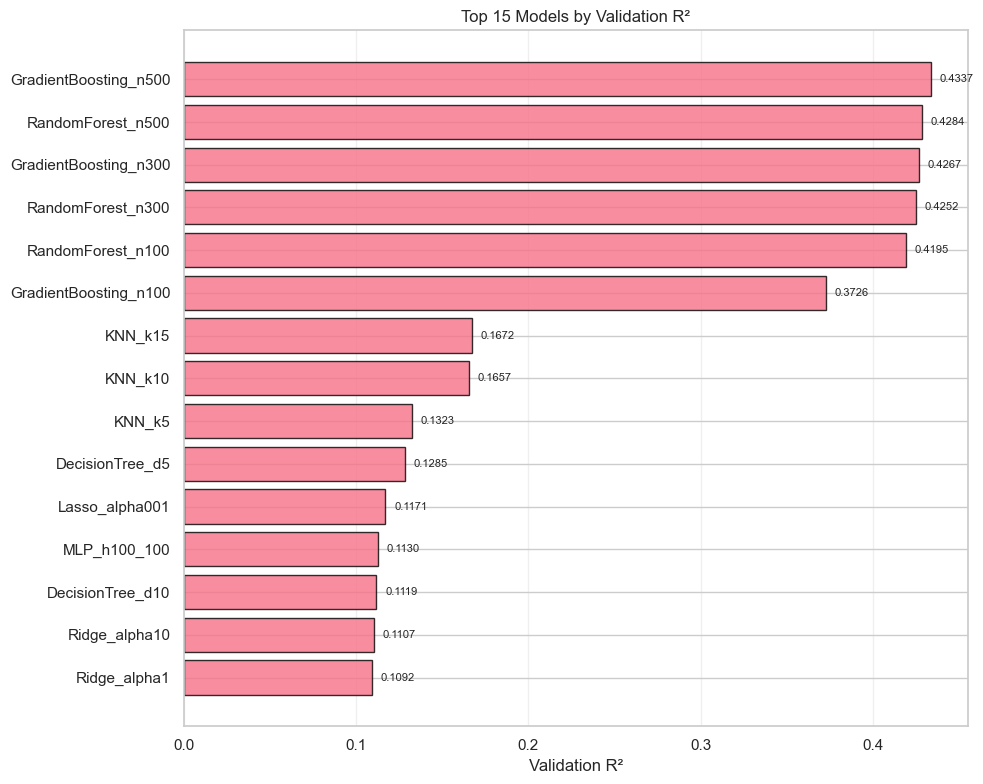

[INFO] Saved: ../figures\01_top_models_val_r2.png


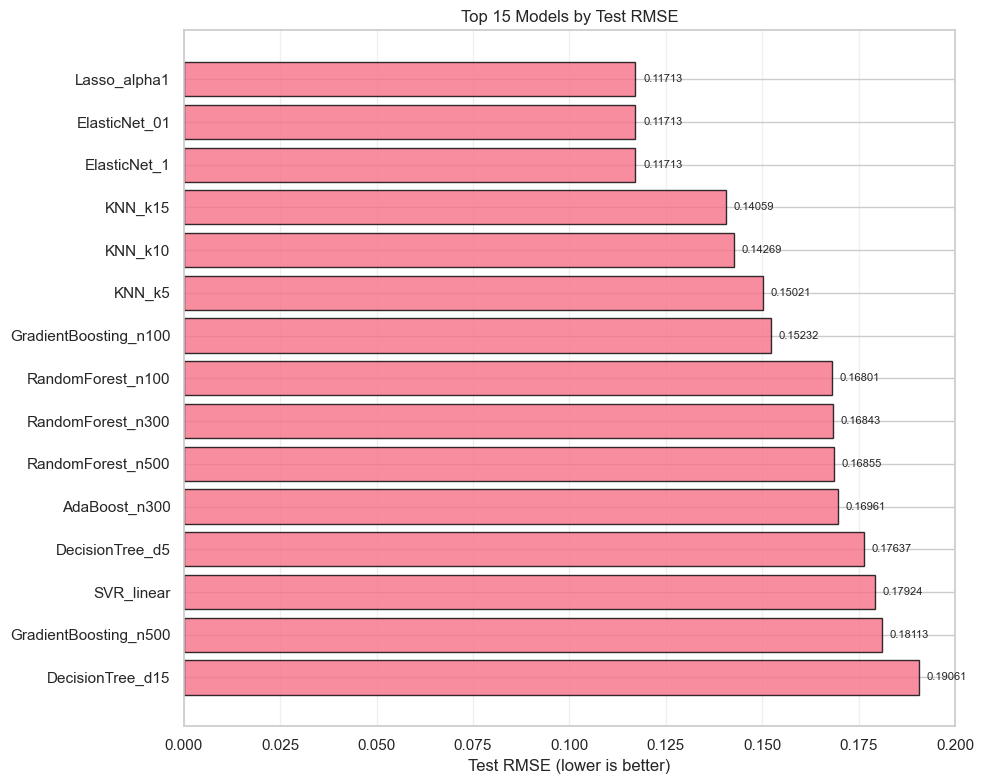

[INFO] Saved: ../figures\02_top_models_test_rmse.png


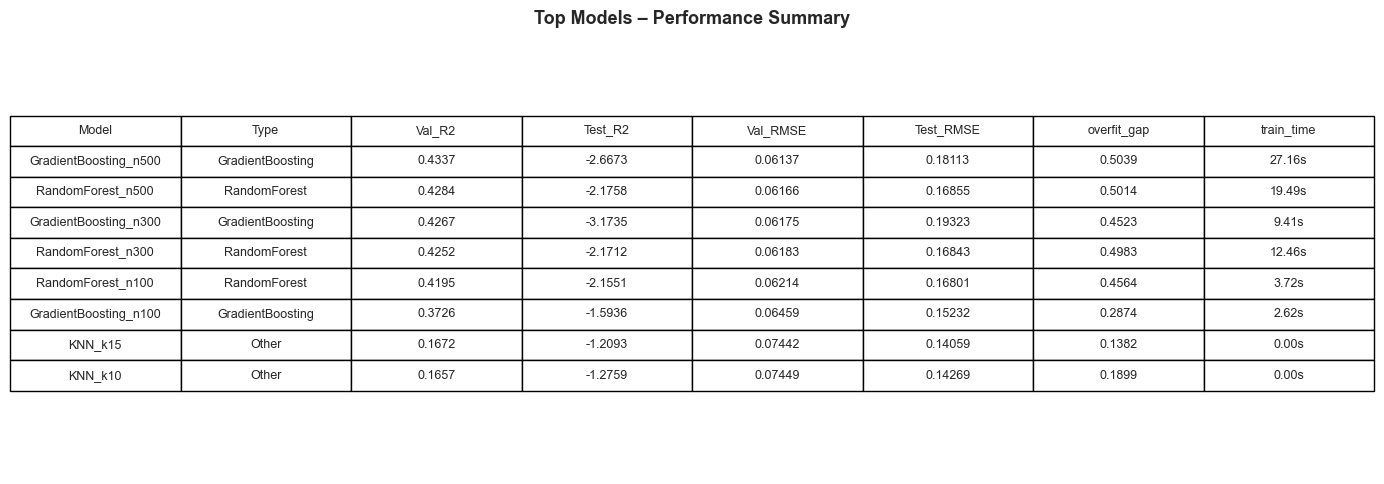

[INFO] Saved: ../figures\03_metrics_table.png


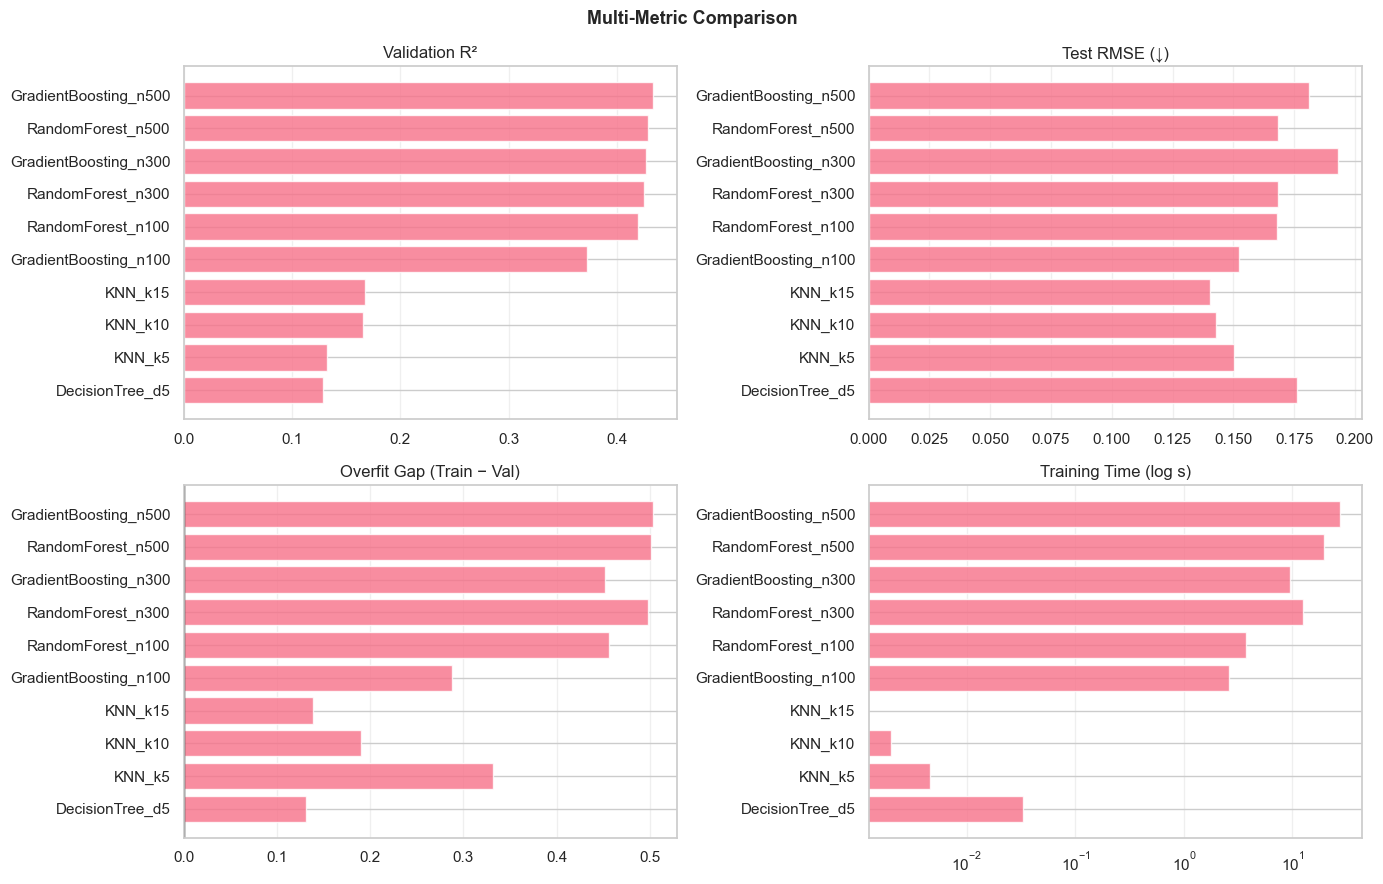

[INFO] Saved: ../figures\04_multimetric_comparison.png


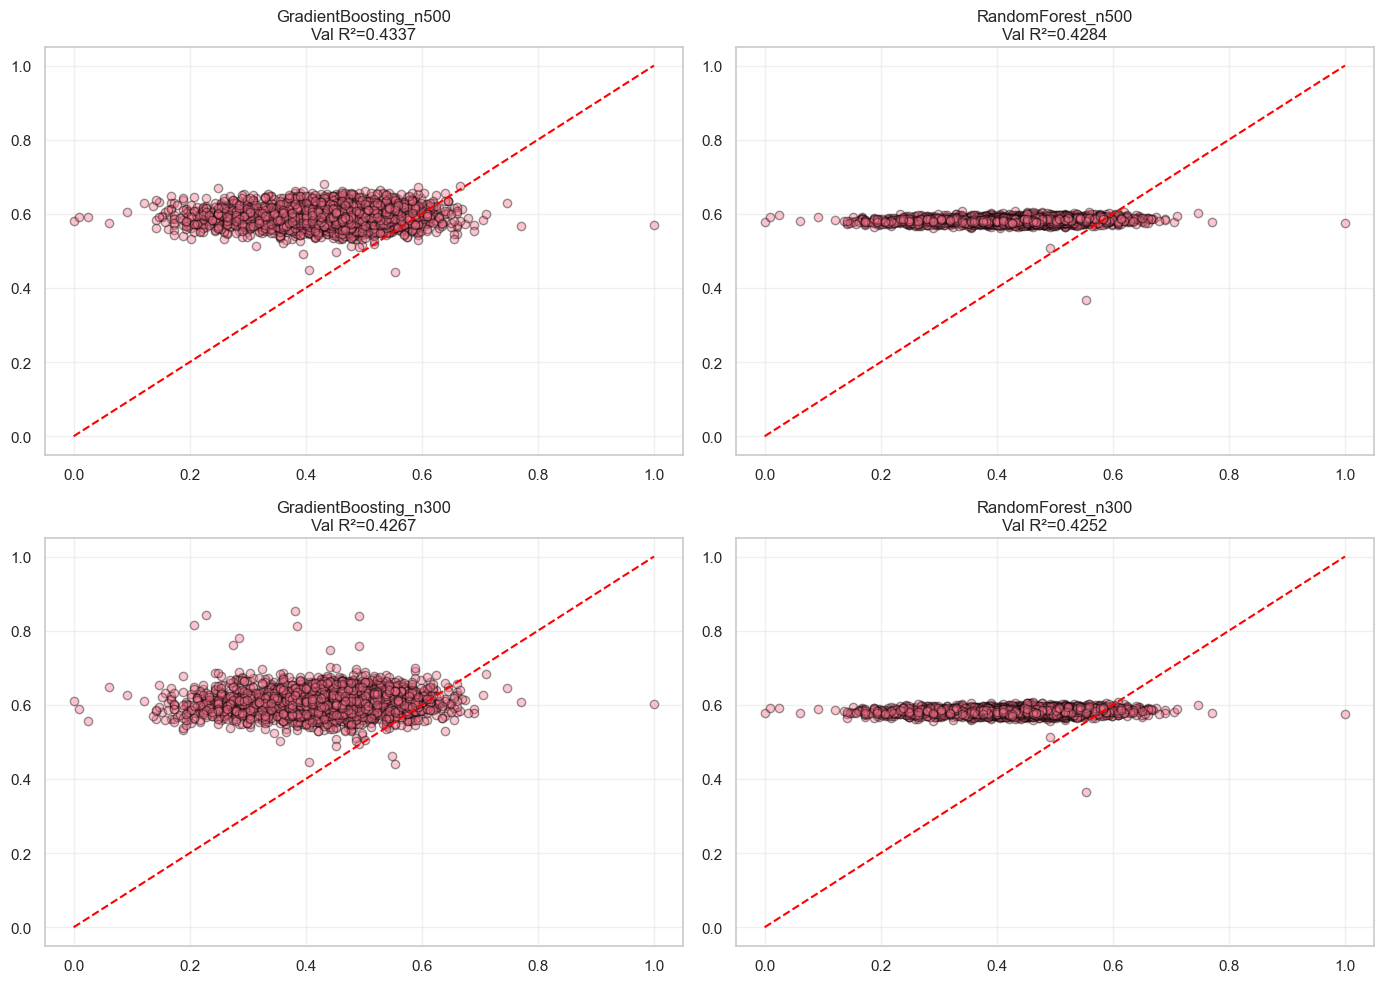

[INFO] Saved: ../figures\06_top4_predictions.png


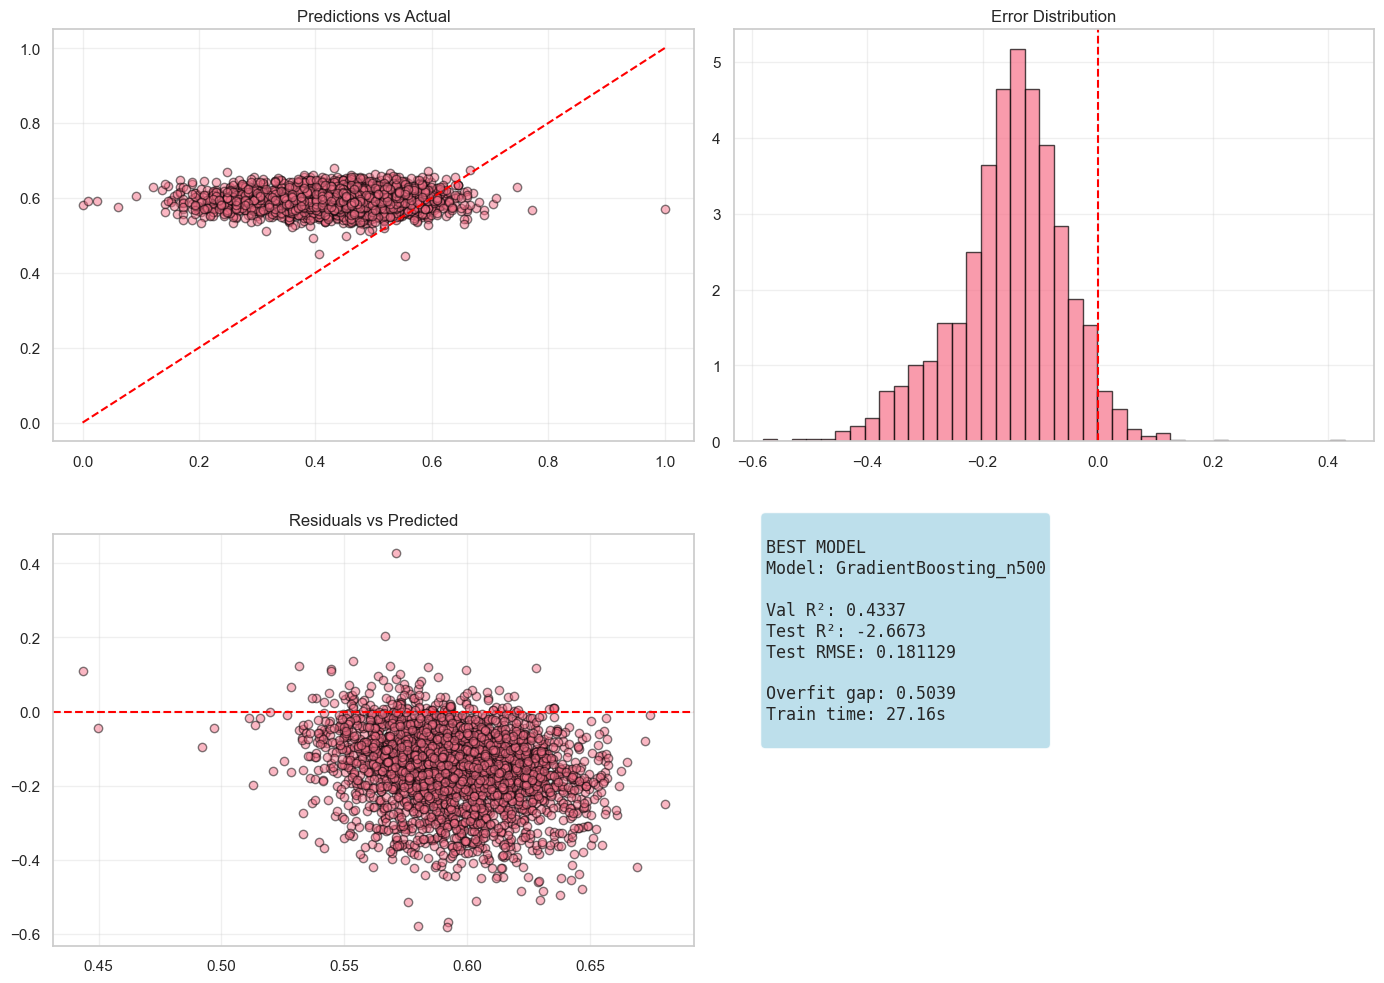

[INFO] Saved: ../figures\07_best_model_detailed.png
[DONE] Figures saved to ../figures


In [49]:
ra.run_results_analysis(
    df_results=df_results,
    predictions=predictions_df,
    y_test=y_test
)


# FINAL SUMMARY


In [50]:

print("\n" + "="*100)
print("PIPELINE EXECUTION COMPLETED")
print("="*100)

# Create summary dictionary (no print, just return data)
PIPELINE_SUMMARY = {
    'status': 'completed',
    'timestamp': pd.Timestamp.now().isoformat(),
    'statistics': {
        'training_samples': int(X_train.shape[0]),
        'validation_samples': int(X_val.shape[0]),
        'test_samples': int(X_test.shape[0]),
        'selected_features': int(X_train.shape[1]),
        'models_trained': int(len(df_results)),
        'best_model': str(df_results.iloc[0]['Model']),
        'best_val_r2': float(df_results['Val_R2'].max()),
        'best_test_r2': float(df_results['Test_R2'].max()),
        'avg_train_time': float(df_results['train_time'].mean()),
        'avg_inference_time': float(df_results['inference_time'].mean()),
    },
    'output_files': {
        'performance_metrics': 'results/performance_metrics.csv',
        'top_10_models': 'results/top_10_models.csv',
        'all_predictions': 'results/predictions/all_predictions.csv',
        'top_5_predictions': 'results/predictions/top_5_predictions.csv',
        'metadata': 'results/metadata.json',
        'preprocessing_info': 'results/preprocessing_info.json',
        'ranking_by_r2': 'results/ranking_by_test_r2.csv',
        'ranking_by_rmse': 'results/ranking_by_test_rmse.csv',
        'ranking_by_time': 'results/ranking_by_train_time.csv',
        'residuals_stats': 'results/residuals_statistics.json',
        'figures': 'figures/',
    }
}

print("\n[PIPELINE SUMMARY]")
print(f"Status: {PIPELINE_SUMMARY['status'].upper()}")
print(f"Best Model: {PIPELINE_SUMMARY['statistics']['best_model']}")
print(f"Best Test R²: {PIPELINE_SUMMARY['statistics']['best_test_r2']:.4f}")
print(f"Models Trained: {PIPELINE_SUMMARY['statistics']['models_trained']}")

print("\n[OUTPUT DIRECTORY STRUCTURE]")
print("""
results/
├── performance_metrics.csv          (Main results table)
├── top_10_models.csv               (Top 10 ranked models)
├── ranking_by_test_r2.csv          (Ranked by R² score)
├── ranking_by_test_rmse.csv        (Ranked by RMSE)
├── ranking_by_train_time.csv       (Ranked by training time)
├── metadata.json                   (Pipeline metadata)
├── preprocessing_info.json         (Feature & scaler info)
├── residuals_statistics.json       (Error statistics)
└── predictions/
    ├── all_predictions.csv         (All model predictions)
    └── top_5_predictions.csv       (Top 5 model predictions)

figures/
├── 01_correlation_matrix.png
├── 02_correlation_with_target.png
├── 03_histograms.png
├── ...
└── 24_multimetric_performance.png
""")

print("="*100)
print("END OF PIPELINE - ALL RESULTS EXPORTED")
print("="*100 + "\n")


PIPELINE EXECUTION COMPLETED

[PIPELINE SUMMARY]
Status: COMPLETED
Best Model: GradientBoosting_n500
Best Test R²: -0.5337
Models Trained: 28

[OUTPUT DIRECTORY STRUCTURE]

results/
├── performance_metrics.csv          (Main results table)
├── top_10_models.csv               (Top 10 ranked models)
├── ranking_by_test_r2.csv          (Ranked by R² score)
├── ranking_by_test_rmse.csv        (Ranked by RMSE)
├── ranking_by_train_time.csv       (Ranked by training time)
├── metadata.json                   (Pipeline metadata)
├── preprocessing_info.json         (Feature & scaler info)
├── residuals_statistics.json       (Error statistics)
└── predictions/
    ├── all_predictions.csv         (All model predictions)
    └── top_5_predictions.csv       (Top 5 model predictions)

figures/
├── 01_correlation_matrix.png
├── 02_correlation_with_target.png
├── 03_histograms.png
├── ...
└── 24_multimetric_performance.png

END OF PIPELINE - ALL RESULTS EXPORTED



In [51]:
final_results = pd.read_csv('results/performance_metrics.csv')

print(final_results.head()) 

                   Model              Type    Val_R2   Test_R2  Train_R2  \
0  GradientBoosting_n500  GradientBoosting  0.433747 -2.667332  0.937619   
1      RandomForest_n500      RandomForest  0.428382 -2.175794  0.929828   
2  GradientBoosting_n300  GradientBoosting  0.426714 -3.173510  0.879019   
3      RandomForest_n300      RandomForest  0.425209 -2.171236  0.923507   
4      RandomForest_n100      RandomForest  0.419474 -2.155133  0.875897   

   Val_RMSE  Test_RMSE  train_time  inference_time  total_time  
0  0.061367   0.181129   27.156453        0.073395   27.229848  
1  0.061657   0.168554   19.490047        0.234836   19.724883  
2  0.061747   0.193225    9.409262        0.033375    9.442638  
3  0.061828   0.168433   12.461670        0.135413   12.597084  
4  0.062135   0.168005    3.717592        0.074819    3.792412  
